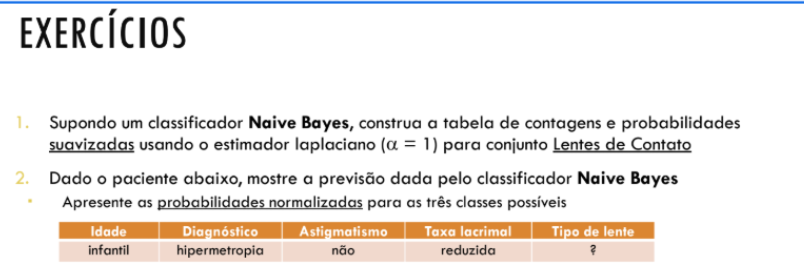

In [25]:
import pandas as pd
from collections import defaultdict

# ================================
# 1. Criar o dataset
# ================================
data = [
    ['infantil', 'miopia', 'não', 'reduzida', 'nenhuma'],
    ['infantil', 'miopia', 'sim', 'normal', 'gelatinosa'],
    ['infantil', 'hipermetropia', 'não', 'normal', 'gelatinosa'],
    ['infantil', 'hipermetropia', 'sim', 'normal', 'dura'],
    ['adolescente', 'miopia', 'não', 'reduzida', 'gelatinosa'],
    ['adolescente', 'miopia', 'sim', 'reduzida', 'nenhuma'],
    ['adolescente', 'miopia', 'não', 'normal', 'dura'],
    ['adolescente', 'hipermetropia', 'não', 'reduzida', 'gelatinosa'],
    ['adolescente', 'hipermetropia', 'sim', 'normal', 'dura'],
    ['adulto', 'miopia', 'não', 'normal', 'gelatinosa'],
    ['adulto', 'miopia', 'sim', 'normal', 'dura'],
    ['adulto', 'miopia', 'sim', 'normal', 'gelatinosa'],
    ['adulto', 'hipermetropia', 'não', 'reduzida', 'nenhuma'],
    ['adulto', 'hipermetropia', 'sim', 'normal', 'gelatinosa'],
    ['adulto', 'hipermetropia', 'não', 'normal', 'gelatinosa'],
]

columns = ['Idade', 'Diagnóstico', 'Astigmatismo', 'Taxa_lacrimal', 'Classe']
df = pd.DataFrame(data, columns=columns)

# ================================
# 2. Parâmetros
# ================================
alpha = 1
features = ['Idade', 'Diagnóstico', 'Astigmatismo', 'Taxa_lacrimal']

# ⚠️ ORDEM FIXA (IMPORTANTE!)
classes = ['gelatinosa', 'dura', 'nenhuma']

# ================================
# 3. Probabilidades a priori
# ================================
class_counts = df['Classe'].value_counts()
total = len(df)
num_classes = len(classes)

priors = {}
for c in classes:
    priors[c] = (class_counts[c] + alpha) / (total + num_classes)

# ================================
# 4. Probabilidades condicionais
# ================================
cond_probs = {}

for feature in features:
    values = df[feature].unique()

    for c in classes:
        subset = df[df['Classe'] == c]
        total_c = len(subset)

        for v in values:
            count = len(subset[subset[feature] == v])
            prob = (count + alpha) / (total_c + len(values))
            cond_probs[(feature, v, c)] = prob

# ================================
# 5. Novo paciente
# ================================
new_sample = {
    'Idade': 'infantil',
    'Diagnóstico': 'hipermetropia',
    'Astigmatismo': 'não',
    'Taxa_lacrimal': 'reduzida'
}

# ================================
# 6. Cálculo das probabilidades
# ================================
results = {}

for c in classes:
    prob = priors[c]

    for feature in features:
        prob *= cond_probs[(feature, new_sample[feature], c)]

    results[c] = prob

# ================================
# 7. Normalização
# ================================
total_prob = sum(results.values())

normalized = {}
for c in classes:
    normalized[c] = results[c] / total_prob

# ================================
# 8. PRINT IGUAL AO EXERCÍCIO
# ================================

print("\n📊 RESULTADO FINAL:\n")

print("Gelatinosa")
print(f"P[Gelatinosa | E] = {results['gelatinosa']:.4f} / ({results['gelatinosa']:.4f} + {results['dura']:.4f} + {results['nenhuma']:.4f}) = {normalized['gelatinosa']*100:.2f}%\n")

print("Dura")
print(f"P[Dura | E] = {results['dura']:.4f} / ({results['gelatinosa']:.4f} + {results['dura']:.4f} + {results['nenhuma']:.4f}) = {normalized['dura']*100:.2f}%\n")

print("Nenhuma")
print(f"P[Nenhuma | E] = {results['nenhuma']:.4f} / ({results['gelatinosa']:.4f} + {results['dura']:.4f} + {results['nenhuma']:.4f}) = {normalized['nenhuma']*100:.2f}%\n")

# ================================
# 9. Classe prevista
# ================================
predicted_class = max(normalized, key=normalized.get)

print("🎯 Classe prevista:")
print(predicted_class.capitalize())


📊 RESULTADO FINAL:

Gelatinosa
P[Gelatinosa | E] = 0.0123 / (0.0123 + 0.0022 + 0.0142) = 42.76%

Dura
P[Dura | E] = 0.0022 / (0.0123 + 0.0022 + 0.0142) = 7.68%

Nenhuma
P[Nenhuma | E] = 0.0142 / (0.0123 + 0.0022 + 0.0142) = 49.56%

🎯 Classe prevista:
Nenhuma
